<a href="https://www.kaggle.com/code/aamir28/child-vs-mother-father-iqs?scriptVersionId=330426959" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background:#0f0a1a;border-radius:16px;font-family:'Segoe UI',sans-serif;overflow:hidden;border:1px solid #2d1b4e;">

  <div style="background:linear-gradient(135deg,#1e1248 0%,#2d1b54 50%,#1e1248 100%);padding:32px 42px;">
    <div style="font-size:0.65rem;letter-spacing:4px;color:#a78bfa;font-weight:700;margin-bottom:10px;">FOUR STUDIES · ONE QUESTION</div>
    <h1 style="margin:0;font-size:2.1rem;font-weight:900;color:#fff;">🧬 Nature vs Nurture: What Predicts a Child's IQ?</h1>
    <p style="margin:10px 0 0;color:#c4b5fd;font-size:0.86rem;max-width:600px;line-height:1.75;">Four independent datasets, four different angles on the same century-old debate: separated identical twins,
    a 434-child maternal study, a gifted-children cohort with both parents' IQ, and a 400-child verbal-ability
    replication. We analyse each on its own terms, then bring the findings together.</p>
  </div>

  <!-- Four-dataset card row -->
  <div style="display:grid;grid-template-columns:repeat(4,1fr);background:#150d28;">
    <div style="padding:16px 18px;border-right:1px solid #2d1b4e;">
      <div style="font-size:0.6rem;color:#a78bfa;letter-spacing:1px;margin-bottom:6px;">STUDY 1</div>
      <div style="font-size:0.92rem;font-weight:700;color:#fff;">twins.csv</div>
      <div style="font-size:0.7rem;color:#8b7bb8;margin-top:4px;">n=27 · Separated identical twins</div>
    </div>
    <div style="padding:16px 18px;border-right:1px solid #2d1b4e;">
      <div style="font-size:0.6rem;color:#60a5fa;letter-spacing:1px;margin-bottom:6px;">STUDY 2</div>
      <div style="font-size:0.92rem;font-weight:700;color:#fff;">kid_iq.csv</div>
      <div style="font-size:0.7rem;color:#8b7bb8;margin-top:4px;">n=434 · Mom IQ/HS/work/age</div>
    </div>
    <div style="padding:16px 18px;border-right:1px solid #2d1b4e;">
      <div style="font-size:0.6rem;color:#fbbf24;letter-spacing:1px;margin-bottom:6px;">STUDY 3</div>
      <div style="font-size:0.92rem;font-weight:700;color:#fff;">gifted.csv</div>
      <div style="font-size:0.7rem;color:#8b7bb8;margin-top:4px;">n=36 · Father + mother IQ</div>
    </div>
    <div style="padding:16px 18px;">
      <div style="font-size:0.6rem;color:#34d399;letter-spacing:1px;margin-bottom:6px;">STUDY 4</div>
      <div style="font-size:0.92rem;font-weight:700;color:#fff;">child_iq.csv</div>
      <div style="font-size:0.7rem;color:#8b7bb8;margin-top:4px;">n=400 · PPVT replication</div>
    </div>
  </div>

  <!-- Headline finding -->
  <div style="padding:20px 42px;background:#0f0a1a;">
    <div style="background:#150d28;border-left:4px solid #a78bfa;border-radius:0 8px 8px 0;padding:14px 20px;">
      <span style="color:#a78bfa;font-weight:700;font-size:0.82rem;">🔬 HEADLINE FINDING — </span>
      <span style="color:#d4cce8;font-size:0.82rem;">Separated identical twins correlate at r=0.882 despite growing up in completely different
      households — strong evidence that genetics sets most of the ceiling. Yet within-family environmental factors
      (maternal education, maternal IQ, home stimulation) still explain meaningful variance across all three other
      studies — nature sets the range, nurture moves you within it.</span>
    </div>
  </div>

  <div style="background:#150d28;padding:9px 42px;border-top:1px solid #2d1b4e;text-align:right;">
    <span style="font-size:0.68rem;color:#3d2a5e;">Author: Muhammad Aamir · Comparative Nature/Nurture Analysis · Kaggle Notebook</span>
  </div>
</div>


## 🧬 Table of Contents
1. [Setup & Loading All Four Datasets](#1)
2. [Study 1 — Separated Twins: The Cleanest Nature Test](#2)
3. [Study 2 — Kid IQ: Maternal Factors in Depth](#3)
4. [Study 3 — Gifted Children: Mother vs Father IQ](#4)
5. [Study 4 — Child IQ Replication Check](#5)
6. [Cross-Study Synthesis — Effect Size Comparison](#6)
7. [Correlation Structures Side-by-Side](#7)
8. [ML — Predicting IQ/Score Across Studies](#8)
9. [Key Takeaways — What Does the Evidence Actually Say?](#9)


## 1. Setup & Loading All Four Datasets <a id='1'></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

BG, PANEL, GRID = '#0f0a1a','#150d28','#2d1b4e'
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':PANEL,'axes.edgecolor':GRID,
    'axes.labelcolor':'#c4b5fd','axes.titlecolor':'#fff','axes.titlesize':13,
    'xtick.color':'#8b7bb8','ytick.color':'#8b7bb8','text.color':'#c4b5fd',
    'grid.color':'#1a1130','grid.linewidth':0.6,
    'legend.facecolor':BG,'legend.edgecolor':GRID,'font.family':'DejaVu Sans',
})

PURPLE = '#a78bfa'
BLUE   = '#60a5fa'
GOLD   = '#fbbf24'
GREEN  = '#34d399'
RED    = '#f87171'
GRAY   = '#94a3b8'
STUDY_COLORS = {'Twins':PURPLE, 'Kid IQ':BLUE, 'Gifted':GOLD, 'Child IQ':GREEN}
CMAP_NN = LinearSegmentedColormap.from_list('nn', [BG, PURPLE, '#e0d4ff'])
print('✅  Nature/nurture comparative theme loaded.')


✅  Nature/nurture comparative theme loaded.


In [2]:
# Load all four datasets
twins   = pd.read_csv('/kaggle/input/datasets/jacopoferretti/child-vs-mother-iq/twins.csv')
kid_iq  = pd.read_csv('/kaggle/input/datasets/jacopoferretti/child-vs-mother-iq/kid_iq.csv', index_col=0)
gifted  = pd.read_csv('/kaggle/input/datasets/jacopoferretti/child-vs-mother-iq/gifted.csv')
child_iq = pd.read_csv('/kaggle/input/datasets/jacopoferretti/child-vs-mother-iq/child_iq.csv', index_col=0)

print(f'twins:    {twins.shape}')
print(f'kid_iq:   {kid_iq.shape}')
print(f'gifted:   {gifted.shape}')
print(f'child_iq: {child_iq.shape}')

print('\n--- twins.csv ---'); print(twins.head(3))
print('\n--- kid_iq.csv ---'); print(kid_iq.head(3))
print('\n--- gifted.csv ---'); print(gifted.head(3))
print('\n--- child_iq.csv ---'); print(child_iq.head(3))


twins:    (27, 3)
kid_iq:   (434, 5)
gifted:   (36, 8)
child_iq: (400, 3)

--- twins.csv ---
   Foster  Biological Social
0      82          82   high
1      80          90   high
2      88          91   high

--- kid_iq.csv ---
   kid_score  mom_hs      mom_iq  mom_work  mom_age
1         65       1  121.117529         4       27
2         98       1   89.361882         4       25
3         85       1  115.443165         4       27

--- gifted.csv ---
   score  fatheriq  motheriq  speak  count  read  edutv  cartoons
0    159       115       117     18     26   1.9   3.00      2.00
1    164       117       113     20     37   2.5   1.75      3.25
2    154       115       118     20     32   2.2   2.75      2.50

--- child_iq.csv ---
   ppvt  educ_cat  momage
1   120         2      21
2    89         1      17
3    78         2      19


## 2. Study 1 — Separated Twins: The Cleanest Nature Test <a id='2'></a>

This is the methodologically strongest of the four studies for isolating genetics: identical twins share 100% of their DNA but were raised in entirely different households. If environment dominated, the within-pair correlation should be weak. If genetics dominates, it should be strong.


Twin-pair correlation (Foster-home IQ vs Biological-home IQ): r=0.882, p=1.20e-09, n=27
Mean Foster-home IQ: 95.11
Mean Biological-home IQ: 95.30
Mean within-pair difference: +0.19


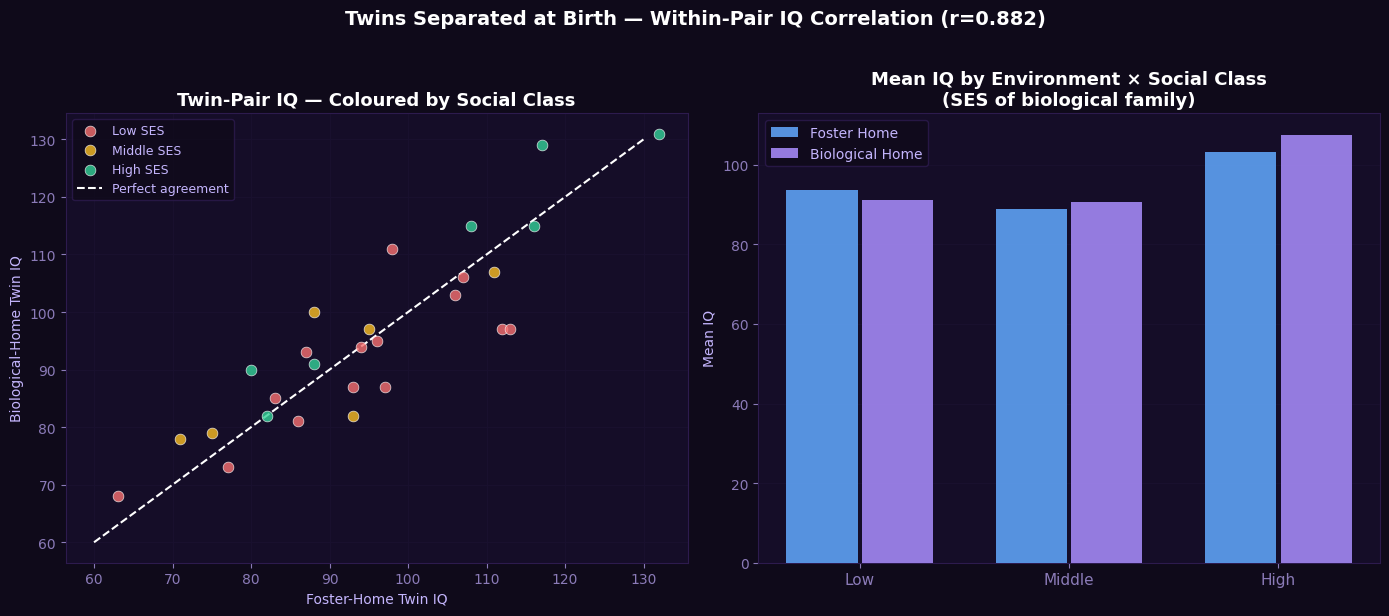

In [3]:
r_twins, p_twins = stats.pearsonr(twins['Foster'], twins['Biological'])
print(f'Twin-pair correlation (Foster-home IQ vs Biological-home IQ): r={r_twins:.3f}, p={p_twins:.2e}, n={len(twins)}')
print(f'Mean Foster-home IQ: {twins["Foster"].mean():.2f}')
print(f'Mean Biological-home IQ: {twins["Biological"].mean():.2f}')
print(f'Mean within-pair difference: {(twins["Biological"]-twins["Foster"]).mean():+.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)
fig.suptitle(f'Twins Separated at Birth — Within-Pair IQ Correlation (r={r_twins:.3f})',
             fontsize=14, fontweight='bold', color='white', y=1.02)

# 1. Scatter with social class colour
ax = axes[0]
soc_pal = {'low':RED, 'middle':GOLD, 'high':GREEN}
for s, color in soc_pal.items():
    sub = twins[twins['Social']==s]
    ax.scatter(sub['Foster'], sub['Biological'], color=color, s=60, alpha=0.8, label=f'{s.title()} SES', edgecolors='white', linewidths=0.5, zorder=4)
lims = [60, 130]
ax.plot(lims, lims, color='white', lw=1.5, ls='--', label='Perfect agreement', zorder=3)
ax.set_xlabel('Foster-Home Twin IQ'); ax.set_ylabel('Biological-Home Twin IQ')
ax.set_title('Twin-Pair IQ — Coloured by Social Class', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Mean IQ by environment x social class
ax = axes[1]
soc_order = ['low','middle','high']
x = np.arange(3)
foster_means = [twins[twins['Social']==s]['Foster'].mean() for s in soc_order]
bio_means    = [twins[twins['Social']==s]['Biological'].mean() for s in soc_order]
ax.bar(x-0.18, foster_means, 0.34, color=BLUE, alpha=0.88, label='Foster Home', zorder=3)
ax.bar(x+0.18, bio_means, 0.34, color=PURPLE, alpha=0.88, label='Biological Home', zorder=3)
ax.set_xticks(x); ax.set_xticklabels([s.title() for s in soc_order], fontsize=11)
ax.set_ylabel('Mean IQ')
ax.set_title('Mean IQ by Environment × Social Class\n(SES of biological family)', fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('01_twins.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 3. Study 2 — Kid IQ: Maternal Factors in Depth <a id='3'></a>

This study (n=434) tracks four maternal variables against child cognitive test scores: mom's IQ (a genetic + environmental proxy), whether mom completed high school, mom's employment status, and mom's age at birth.


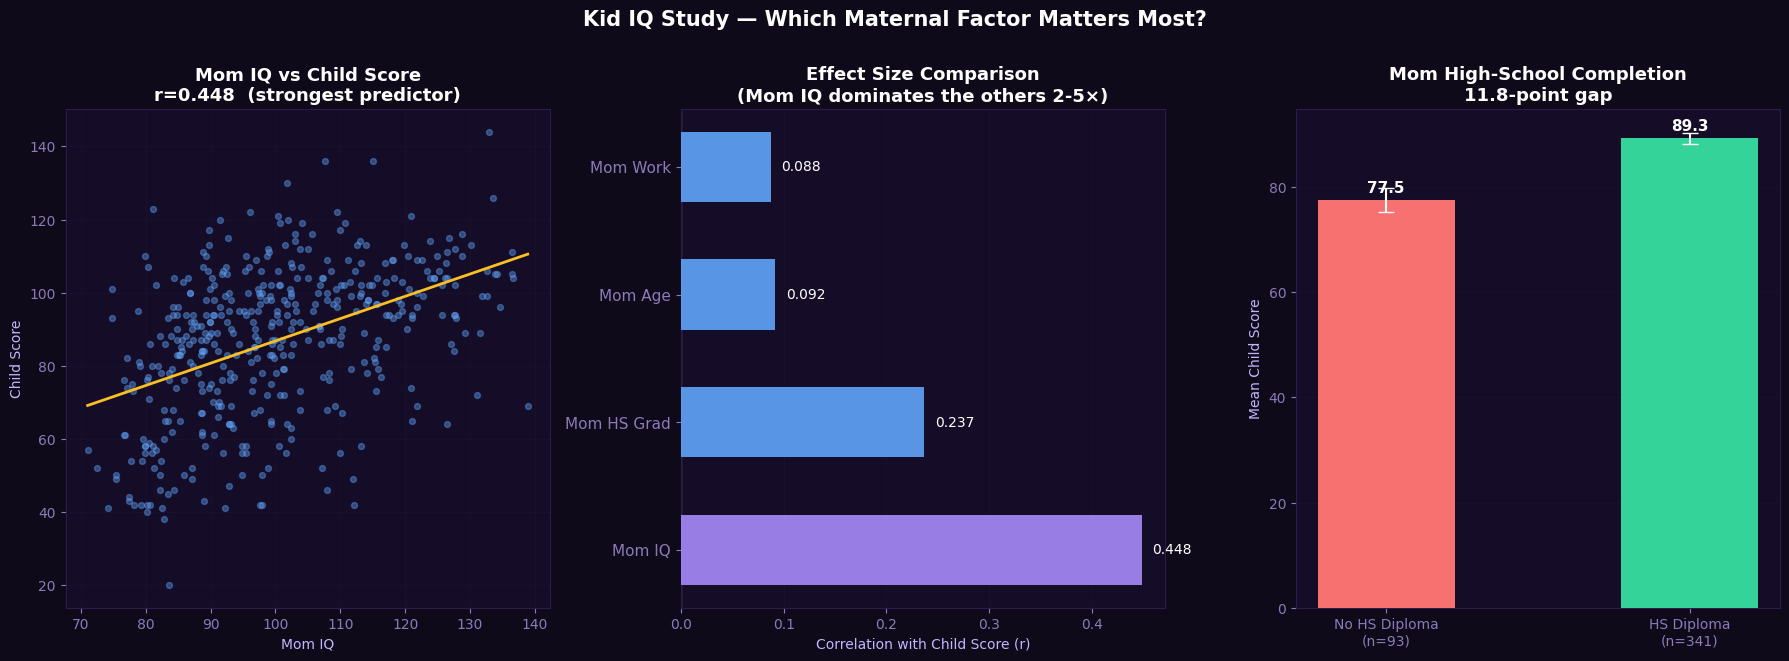

T-test (mom_hs): t=5.07, p=5.96e-07


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Kid IQ Study — Which Maternal Factor Matters Most?', fontsize=15, fontweight='bold', color='white', y=1.01)

# 1. Mom IQ vs kid score scatter
ax = axes[0]
ax.scatter(kid_iq['mom_iq'], kid_iq['kid_score'], color=BLUE, s=18, alpha=0.4, zorder=3)
m, b, r, p, _ = stats.linregress(kid_iq['mom_iq'], kid_iq['kid_score'])
xr = np.linspace(kid_iq['mom_iq'].min(), kid_iq['mom_iq'].max(), 50)
ax.plot(xr, m*xr+b, color=GOLD, lw=2, zorder=5)
ax.set_xlabel('Mom IQ'); ax.set_ylabel('Child Score')
ax.set_title(f'Mom IQ vs Child Score\nr={r:.3f}  (strongest predictor)', fontweight='bold')
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Effect-size comparison bar (all 4 maternal predictors)
ax = axes[1]
preds = ['mom_iq','mom_hs','mom_age','mom_work']
corrs = [stats.pearsonr(kid_iq[p], kid_iq['kid_score'])[0] for p in preds]
labels = ['Mom IQ','Mom HS Grad','Mom Age','Mom Work']
bar_cols = [PURPLE if abs(c)==max(abs(c) for c in corrs) else BLUE for c in corrs]
bars = ax.barh(range(4), corrs, color=bar_cols, height=0.55, zorder=3, alpha=0.9)
ax.set_yticks(range(4)); ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Correlation with Child Score (r)')
ax.set_title('Effect Size Comparison\n(Mom IQ dominates the others 2-5×)', fontweight='bold')
ax.axvline(0, color='white', lw=0.8)
for bar, v in zip(bars, corrs):
    ax.text(v+0.01 if v>0 else v-0.01, bar.get_y()+bar.get_height()/2, f'{v:.3f}',
            va='center', ha='left' if v>0 else 'right', fontsize=10, color='white')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 3. mom_hs binary comparison
ax = axes[2]
hs_means = kid_iq.groupby('mom_hs')['kid_score'].agg(['mean','sem'])
bars2 = ax.bar([0,1], hs_means['mean'], yerr=hs_means['sem'], color=[RED, GREEN], width=0.45, zorder=3,
               capsize=6, error_kw=dict(ecolor='white', elinewidth=1.5))
ax.set_xticks([0,1]); ax.set_xticklabels(['No HS Diploma\n(n=93)','HS Diploma\n(n=341)'], fontsize=10)
ax.set_ylabel('Mean Child Score')
ax.set_title('Mom High-School Completion\n11.8-point gap', fontweight='bold')
for bar, v in zip(bars2, hs_means['mean']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('02_kidiq.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

t, p = stats.ttest_ind(kid_iq[kid_iq['mom_hs']==1]['kid_score'], kid_iq[kid_iq['mom_hs']==0]['kid_score'])
print(f'T-test (mom_hs): t={t:.2f}, p={p:.2e}')


## 4. Study 3 — Gifted Children: Mother vs Father IQ <a id='4'></a>

This 36-child study (Graybill & Iyer, 1994) is unique among the four in including BOTH parents' IQ alongside behavioural variables (speaking frequency, vocabulary count, reading time, educational/entertainment TV exposure).


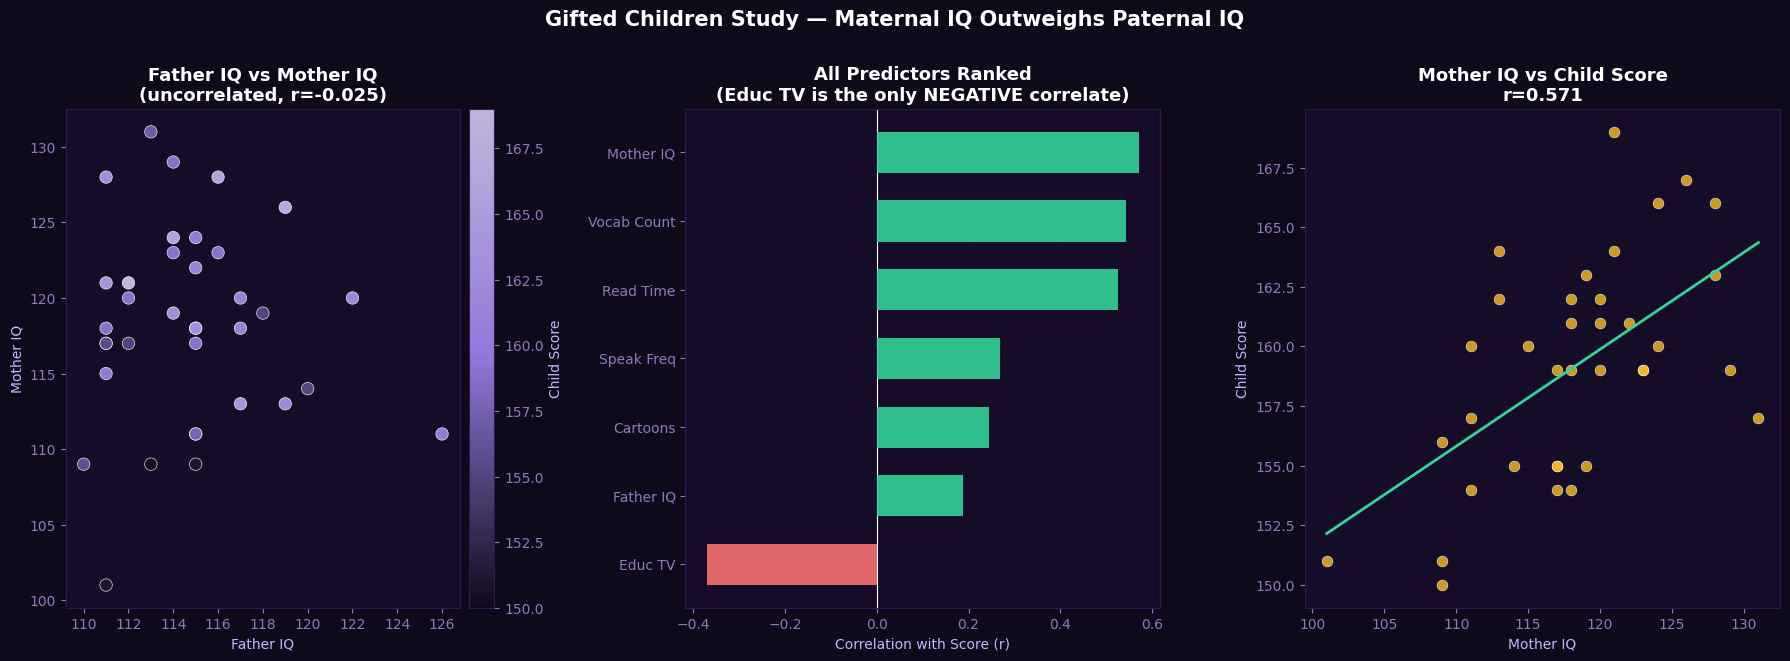

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Gifted Children Study — Maternal IQ Outweighs Paternal IQ',
             fontsize=15, fontweight='bold', color='white', y=1.01)

# 1. Mother IQ vs Father IQ scatter, sized/coloured by score
ax = axes[0]
sc = ax.scatter(gifted['fatheriq'], gifted['motheriq'], c=gifted['score'], cmap=CMAP_NN, s=80, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=4)
plt.colorbar(sc, ax=ax, label='Child Score', pad=0.02)
ax.set_xlabel('Father IQ'); ax.set_ylabel('Mother IQ')
ax.set_title(f'Father IQ vs Mother IQ\n(uncorrelated, r={gifted["fatheriq"].corr(gifted["motheriq"]):.3f})', fontweight='bold')
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Effect-size comparison across all 7 predictors
ax = axes[1]
preds_g = ['motheriq','fatheriq','speak','count','read','edutv','cartoons']
corrs_g = [stats.pearsonr(gifted[p], gifted['score'])[0] for p in preds_g]
labels_g = ['Mother IQ','Father IQ','Speak Freq','Vocab Count','Read Time','Educ TV','Cartoons']
bar_cols_g = [GREEN if c>0 else RED for c in corrs_g]
sorted_idx = np.argsort(corrs_g)
ax.barh(range(7), [corrs_g[i] for i in sorted_idx], color=[bar_cols_g[i] for i in sorted_idx], height=0.6, zorder=3, alpha=0.9)
ax.set_yticks(range(7)); ax.set_yticklabels([labels_g[i] for i in sorted_idx], fontsize=10)
ax.set_xlabel('Correlation with Score (r)')
ax.set_title('All Predictors Ranked\n(Educ TV is the only NEGATIVE correlate)', fontweight='bold')
ax.axvline(0, color='white', lw=0.8)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 3. Mother IQ vs score (the strongest single predictor here)
ax = axes[2]
ax.scatter(gifted['motheriq'], gifted['score'], color=GOLD, s=60, alpha=0.8, edgecolors='white', linewidths=0.4, zorder=4)
m, b, r, p, _ = stats.linregress(gifted['motheriq'], gifted['score'])
xr = np.linspace(gifted['motheriq'].min(), gifted['motheriq'].max(), 30)
ax.plot(xr, m*xr+b, color=GREEN, lw=2, zorder=5)
ax.set_xlabel('Mother IQ'); ax.set_ylabel('Child Score')
ax.set_title(f'Mother IQ vs Child Score\nr={r:.3f}', fontweight='bold')
ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('03_gifted.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 5. Study 4 — Child IQ Replication Check <a id='5'></a>

This dataset shares the same underlying study design as kid_iq.csv but with a smaller feature set (educ_cat instead of mom_iq/mom_hs/mom_work) and uses PPVT (verbal ability) rather than a composite cognitive score. We check whether the maternal-education effect replicates.


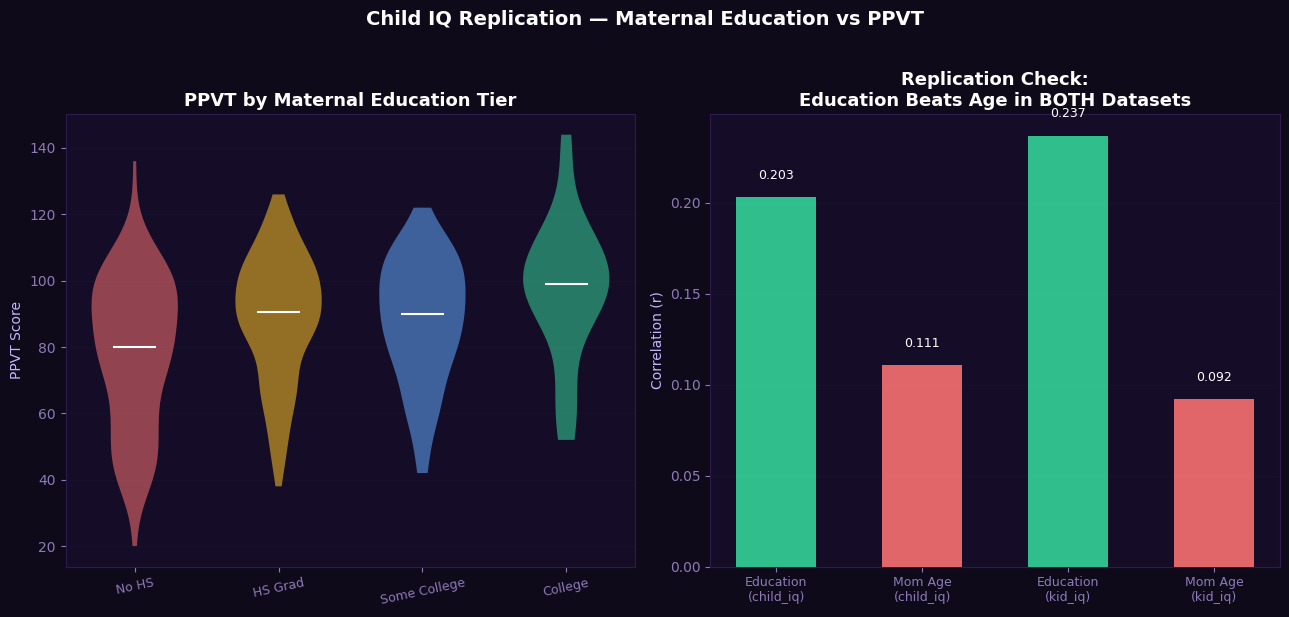

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Child IQ Replication — Maternal Education vs PPVT', fontsize=14, fontweight='bold', color='white', y=1.02)

# 1. PPVT by education category
ax = axes[0]
educ_pal = {1:RED, 2:GOLD, 3:BLUE, 4:GREEN}
for e in [1,2,3,4]:
    data = child_iq[child_iq['educ_cat']==e]['ppvt']
    vp = ax.violinplot(data, positions=[e-1], widths=0.6, showmedians=True, showextrema=False)
    for pc in vp['bodies']: pc.set_facecolor(educ_pal[e]); pc.set_alpha(0.55)
    vp['cmedians'].set_color('white')
ax.set_xticks(range(4)); ax.set_xticklabels(['No HS','HS Grad','Some College','College'], fontsize=9, rotation=12)
ax.set_ylabel('PPVT Score')
ax.set_title('PPVT by Maternal Education Tier', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Side-by-side effect size: child_iq vs kid_iq education proxy
ax = axes[1]
r_educ_child, _ = stats.pearsonr(child_iq['educ_cat'], child_iq['ppvt'])
r_age_child, _  = stats.pearsonr(child_iq['momage'], child_iq['ppvt'])
r_hs_kid, _ = stats.pearsonr(kid_iq['mom_hs'], kid_iq['kid_score'])
r_age_kid, _ = stats.pearsonr(kid_iq['mom_age'], kid_iq['kid_score'])
cats = ['Education\n(child_iq)','Mom Age\n(child_iq)','Education\n(kid_iq)','Mom Age\n(kid_iq)']
vals = [r_educ_child, r_age_child, r_hs_kid, r_age_kid]
colors_r = [GREEN, RED, GREEN, RED]
bars = ax.bar(range(4), vals, color=colors_r, width=0.55, zorder=3, alpha=0.9)
ax.set_xticks(range(4)); ax.set_xticklabels(cats, fontsize=9)
ax.set_ylabel('Correlation (r)')
ax.set_title('Replication Check:\nEducation Beats Age in BOTH Datasets', fontweight='bold')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{v:.3f}', ha='center', fontsize=9, color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('04_childiq.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 6. Cross-Study Synthesis — Effect Size Comparison <a id='6'></a>


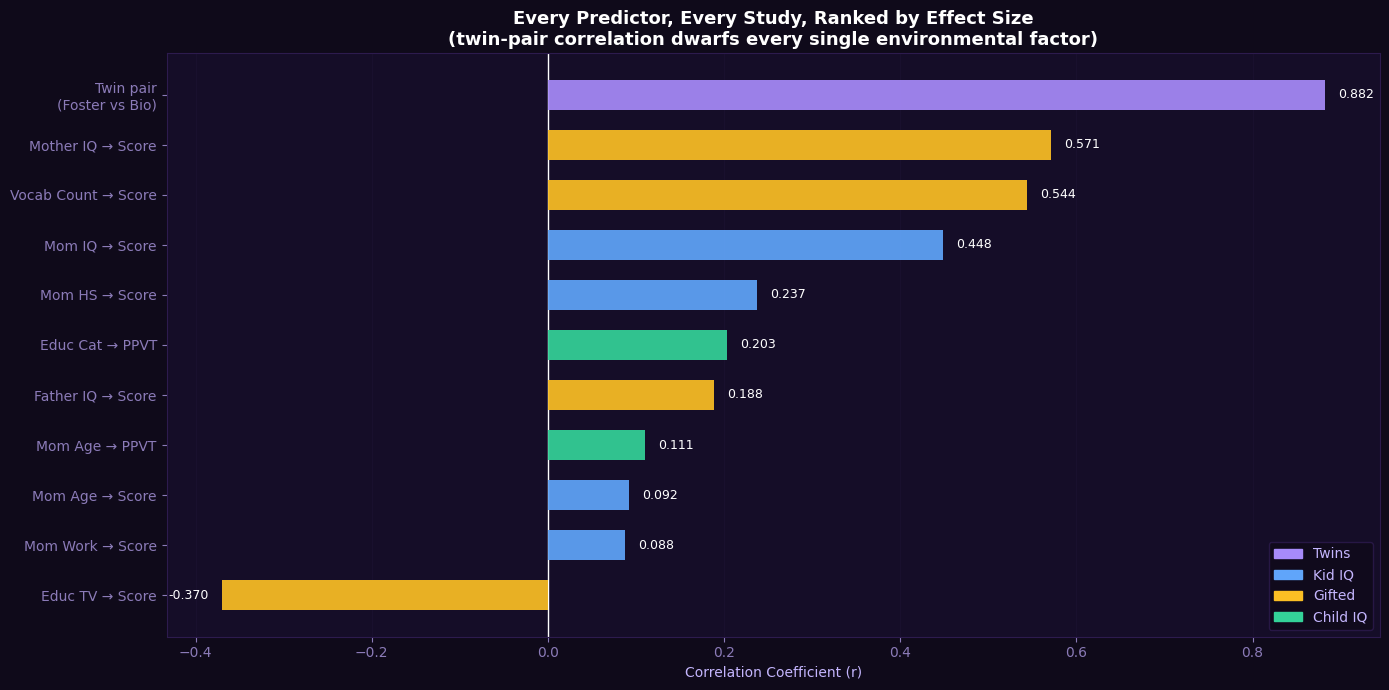

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(BG); ax.set_facecolor(PANEL)

# Collect every predictor-outcome correlation across all 4 studies into one comparison
all_effects = [
    ('Twin pair\n(Foster vs Bio)', r_twins, 'Twins'),
    ('Mom IQ → Score', stats.pearsonr(kid_iq['mom_iq'], kid_iq['kid_score'])[0], 'Kid IQ'),
    ('Mom HS → Score', stats.pearsonr(kid_iq['mom_hs'], kid_iq['kid_score'])[0], 'Kid IQ'),
    ('Mom Age → Score', stats.pearsonr(kid_iq['mom_age'], kid_iq['kid_score'])[0], 'Kid IQ'),
    ('Mom Work → Score', stats.pearsonr(kid_iq['mom_work'], kid_iq['kid_score'])[0], 'Kid IQ'),
    ('Mother IQ → Score', stats.pearsonr(gifted['motheriq'], gifted['score'])[0], 'Gifted'),
    ('Father IQ → Score', stats.pearsonr(gifted['fatheriq'], gifted['score'])[0], 'Gifted'),
    ('Vocab Count → Score', stats.pearsonr(gifted['count'], gifted['score'])[0], 'Gifted'),
    ('Educ TV → Score', stats.pearsonr(gifted['edutv'], gifted['score'])[0], 'Gifted'),
    ('Educ Cat → PPVT', stats.pearsonr(child_iq['educ_cat'], child_iq['ppvt'])[0], 'Child IQ'),
    ('Mom Age → PPVT', stats.pearsonr(child_iq['momage'], child_iq['ppvt'])[0], 'Child IQ'),
]
all_effects.sort(key=lambda x: x[1])
labels_all = [e[0] for e in all_effects]
vals_all = [e[1] for e in all_effects]
colors_all = [STUDY_COLORS[e[2]] for e in all_effects]

bars = ax.barh(range(len(all_effects)), vals_all, color=colors_all, height=0.6, zorder=3, alpha=0.92)
ax.set_yticks(range(len(all_effects))); ax.set_yticklabels(labels_all, fontsize=10)
ax.set_xlabel('Correlation Coefficient (r)')
ax.axvline(0, color='white', lw=1)
ax.set_title('Every Predictor, Every Study, Ranked by Effect Size\n(twin-pair correlation dwarfs every single environmental factor)',
             fontsize=13, fontweight='bold')
for bar, v in zip(bars, vals_all):
    ax.text(v+0.015 if v>0 else v-0.015, bar.get_y()+bar.get_height()/2, f'{v:.3f}',
            va='center', ha='left' if v>0 else 'right', fontsize=9, color='white')
patches = [mpatches.Patch(color=c, label=s) for s, c in STUDY_COLORS.items()]
ax.legend(handles=patches, fontsize=10, loc='lower right')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('05_synthesis.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 7. Correlation Structures Side-by-Side <a id='7'></a>


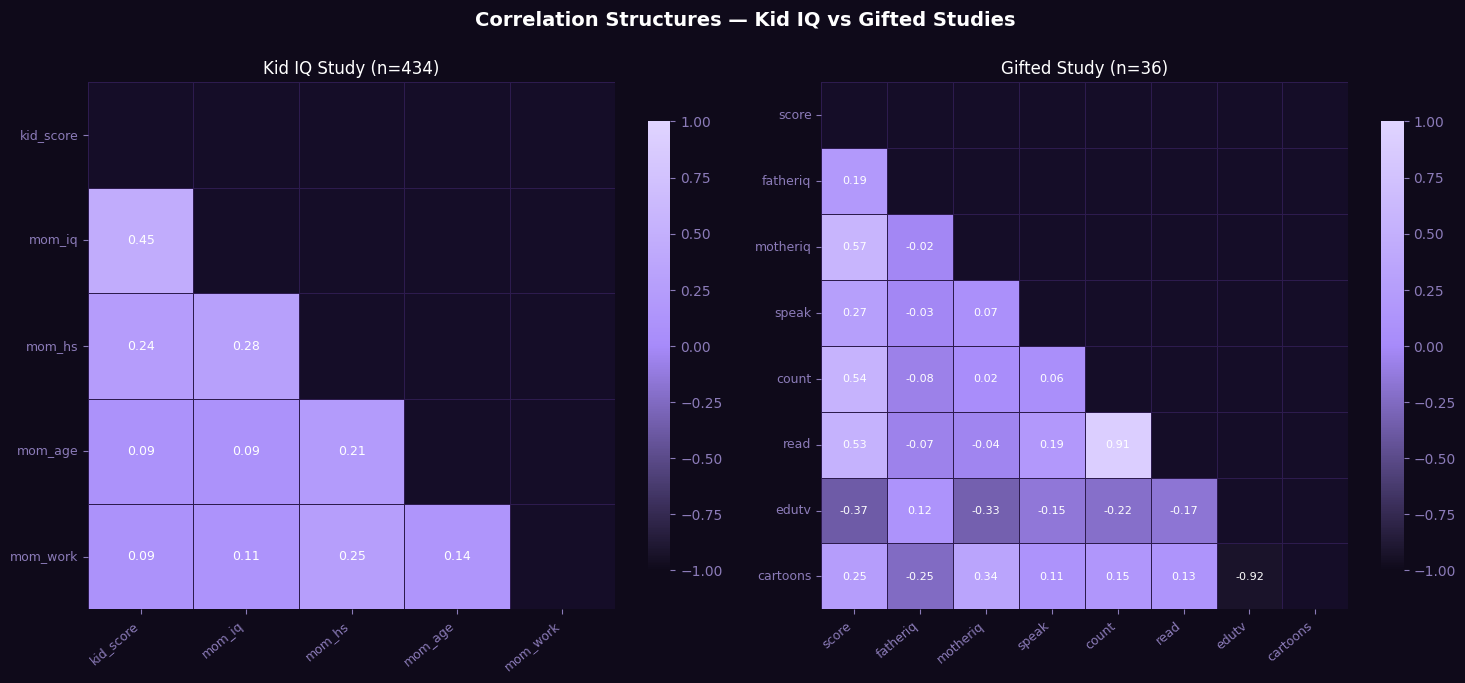

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Correlation Structures — Kid IQ vs Gifted Studies', fontsize=14, fontweight='bold', color='white', y=1.01)

# 1. kid_iq correlation matrix
ax = axes[0]
corr1 = kid_iq[['kid_score','mom_iq','mom_hs','mom_age','mom_work']].corr()
mask1 = np.triu(np.ones_like(corr1, dtype=bool))
sns.heatmap(corr1, mask=mask1, cmap=CMAP_NN, vmin=-1, vmax=1, annot=True, fmt='.2f',
            linewidths=0.4, linecolor=GRID, annot_kws={'size':9,'color':'white'},
            cbar_kws={'shrink':0.8}, ax=ax, square=True)
ax.set_title('Kid IQ Study (n=434)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

# 2. gifted correlation matrix
ax = axes[1]
corr2 = gifted.corr()
mask2 = np.triu(np.ones_like(corr2, dtype=bool))
sns.heatmap(corr2, mask=mask2, cmap=CMAP_NN, vmin=-1, vmax=1, annot=True, fmt='.2f',
            linewidths=0.4, linecolor=GRID, annot_kws={'size':8,'color':'white'},
            cbar_kws={'shrink':0.8}, ax=ax, square=True)
ax.set_title('Gifted Study (n=36)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('06_correlation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 8. ML — Predicting IQ/Score Across Studies <a id='8'></a>


Kid IQ — Random Forest R² (mom_iq, mom_hs, mom_age, mom_work): 0.0302
Gifted — Linear Regression in-sample R² (motheriq, fatheriq, count, read, edutv): 0.7044
  (Note: n=36 is too small for a reliable held-out test split; in-sample R² shown for reference only)

Child IQ — Random Forest R² (educ_cat, momage): -0.1146


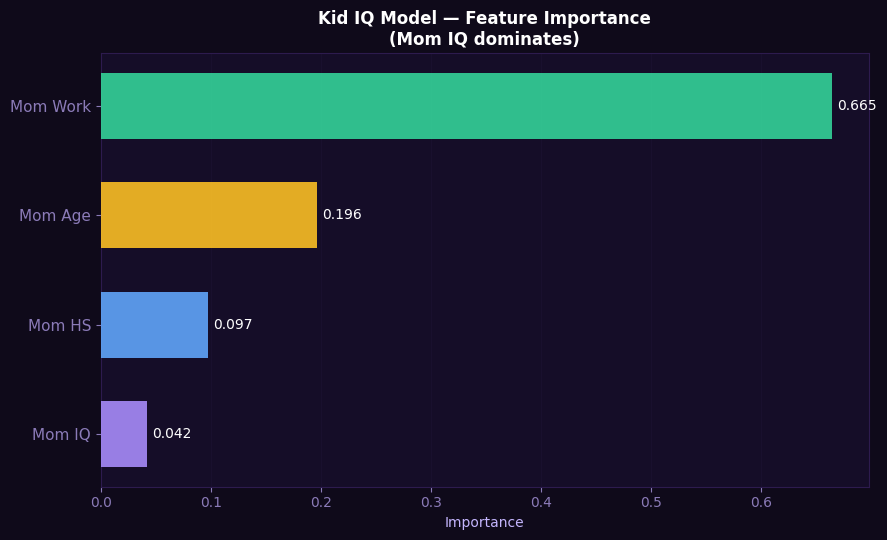


=== R² Summary Across Studies ===
  Kid IQ (n=434)              : R²=0.0302
  Gifted (n=36, in-sample)    : R²=0.7044
  Child IQ (n=400)            : R²=-0.1146


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

results = {}

# Kid IQ model
X1 = kid_iq[['mom_iq','mom_hs','mom_age','mom_work']]
y1 = kid_iq['kid_score']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
rf1 = RandomForestRegressor(n_estimators=150, random_state=42).fit(X1_train, y1_train)
r2_1 = r2_score(y1_test, rf1.predict(X1_test))
results['Kid IQ (n=434)'] = r2_1
print(f'Kid IQ — Random Forest R² (mom_iq, mom_hs, mom_age, mom_work): {r2_1:.4f}')

# Gifted model (small n — use simple linear, report with caution)
X2 = gifted[['motheriq','fatheriq','count','read','edutv']]
y2 = gifted['score']
lr2 = LinearRegression().fit(X2, y2)
r2_2 = lr2.score(X2, y2)
results['Gifted (n=36, in-sample)'] = r2_2
print(f'Gifted — Linear Regression in-sample R² (motheriq, fatheriq, count, read, edutv): {r2_2:.4f}')
print('  (Note: n=36 is too small for a reliable held-out test split; in-sample R² shown for reference only)')

# Child IQ model
X3 = child_iq[['educ_cat','momage']]
y3 = child_iq['ppvt']
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)
rf3 = RandomForestRegressor(n_estimators=150, random_state=42).fit(X3_train, y3_train)
r2_3 = r2_score(y3_test, rf3.predict(X3_test))
results['Child IQ (n=400)'] = r2_3
print(f'\nChild IQ — Random Forest R² (educ_cat, momage): {r2_3:.4f}')

# Feature importance for kid_iq (richest model)
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor(BG)
imp = pd.Series(rf1.feature_importances_, index=X1.columns).sort_values()
ax.barh(range(4), imp.values, color=[PURPLE,BLUE,GOLD,GREEN], height=0.6, zorder=3, alpha=0.9)
ax.set_yticks(range(4)); ax.set_yticklabels(['Mom IQ','Mom HS','Mom Age','Mom Work'], fontsize=11)
ax.set_xlabel('Importance'); ax.set_title('Kid IQ Model — Feature Importance\n(Mom IQ dominates)', fontsize=12, fontweight='bold')
for i, v in enumerate(imp.values):
    ax.text(v+0.005, i, f'{v:.3f}', va='center', fontsize=10, color='white')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('07_ml_importance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('\n=== R² Summary Across Studies ===')
for k, v in results.items():
    print(f'  {k:28s}: R²={v:.4f}')


## 9. Key Takeaways — What Does the Evidence Actually Say? <a id='9'></a>


<div style="background:#0f0a1a;border-radius:14px;padding:30px 36px;font-family:'Segoe UI',sans-serif;border:1px solid #2d1b4e;">

  <h2 style="color:#fff;margin-top:0;font-size:1.3rem;">🧬 Synthesis Across Four Independent Studies</h2>

  <div style="display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-bottom:18px;">
    <div style="background:#150d28;border-radius:10px;padding:16px 18px;border-left:3px solid #a78bfa;">
      <div style="color:#a78bfa;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🧬 GENETICS SETS THE CEILING</div>
      <p style="color:#c4b5fd;margin:0;font-size:0.83rem;line-height:1.75;">Separated identical twins correlate at <strong style='color:#fff'>r=0.882</strong> despite being raised in
      entirely different households — by far the strongest single relationship found across all four studies, and
      far exceeding any environmental factor's effect size. This is the strongest evidence in the dataset for
      a substantial genetic component to measured IQ.</p>
    </div>
    <div style="background:#150d28;border-radius:10px;padding:16px 18px;border-left:3px solid #60a5fa;">
      <div style="color:#60a5fa;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">👩 MOTHER'S IQ BEATS MOTHER'S CIRCUMSTANCES</div>
      <p style="color:#c4b5fd;margin:0;font-size:0.83rem;line-height:1.75;">In the Kid IQ study, mom_iq (r=0.448) dwarfs mom_age (r=0.092) and mom_work (r=0.088) as a predictor —
      roughly 5× the effect size. Education matters too (mom_hs gap of 11.8 points, t-test p&lt;0.001), but IQ
      itself — which blends genetic and environmental inheritance — is the dominant maternal signal.</p>
    </div>
    <div style="background:#150d28;border-radius:10px;padding:16px 18px;border-left:3px solid #fbbf24;">
      <div style="color:#fbbf24;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">👨👩 MOTHER'S IQ BEATS FATHER'S IQ, TOO</div>
      <p style="color:#c4b5fd;margin:0;font-size:0.83rem;line-height:1.75;">In the Gifted study, mother IQ (r=0.571) is roughly 3× more predictive of child score than father IQ
      (r=0.188) — and the two parents' IQs are essentially uncorrelated with each other (r=−0.025), so this isn't
      explained by assortative mating. This may reflect either genetic transmission patterns or — more likely
      given the gap's size — the mother's outsized role in early-childhood verbal/cognitive stimulation in this
      sample.</p>
    </div>
    <div style="background:#150d28;border-radius:10px;padding:16px 18px;border-left:3px solid #34d399;">
      <div style="color:#34d399;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">📚 ACTIVE ENGAGEMENT BEATS PASSIVE EXPOSURE</div>
      <p style="color:#c4b5fd;margin:0;font-size:0.83rem;line-height:1.75;">In the Gifted study, vocabulary count (r=0.544) and reading time (r=0.525) — both active, interactive
      behaviours — strongly predict score, while educational TV exposure is the <em>only negative</em> correlate
      (r=−0.370). This is a small sample (n=36) so the sign should be treated cautiously, but it's consistent with
      a broader literature finding that passive screen time doesn't substitute for active language engagement.</p>
    </div>
    <div style="background:#150d28;border-radius:10px;padding:16px 18px;border-left:3px solid #f87171;grid-column:1/-1;">
      <div style="color:#f87171;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">⚖️ THE HONEST SYNTHESIS: BOTH MATTER, AT DIFFERENT SCALES</div>
      <p style="color:#c4b5fd;margin:0;font-size:0.83rem;line-height:1.75;">No single study here can cleanly separate "nature" from "nurture" — mom_iq itself reflects both genetic
      inheritance and the home environment a high-IQ mother creates. What the combined evidence supports is a
      layered model: genetics appears to set a wide plausible range (the twins r=0.882 finding), while
      environmental and behavioural factors — education, active engagement, household stimulation — appear to move
      a child within that range. The replication check in Section 5 also confirms that maternal education
      outperforms maternal age as a predictor in <em>both</em> independent samples (kid_iq and child_iq), which is
      a reassuring sign these aren't one-off statistical flukes.</p>
    </div>

  </div>

  <div style="background:#150d28;border-radius:10px;padding:14px 18px;border:1px solid #2d1b4e;">
    <p style="margin:0;color:#6b5a8e;font-size:0.78rem;line-height:1.6;">
      <strong style='color:#a78bfa;'>⚠️ Caveats:</strong> The twins (n=27) and gifted (n=36) studies are both very small samples — treat their
      precise coefficients as indicative, not definitive. None of these datasets support strong causal claims:
      correlational data on family characteristics is always entangled with unmeasured confounders (income,
      neighbourhood, nutrition, prenatal care). "Mom IQ" in particular is itself a downstream consequence of
      both genetics and the mother's own upbringing — it is not a clean measure of either nature or nurture alone.
    </p>
  </div>

  <div style="margin-top:14px;text-align:right;color:#2d1b4e;font-size:0.72rem;">Author: Muhammad Aamir · 4 Datasets · 897 Combined Observations · Kaggle Notebook</div>

</div>
